# 第3章 债券与利率风险

校园创新社团提出借款10,000元，并承诺按时支付利息。项目需要判断：这份合同今天值多少钱，利率变化又会带来多大影响？

先列出每笔付款，再计算今天的价格，并检查利率变化带来的影响。

![债券现金流、贴现与利率风险关系](assets/course/03_bond_mechanism.png)




In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 3.1 债券是一组带条件的未来付款承诺

已有线索：第2章已经学过不同时间的钱不能直接相加。本节要解决：**面值1000元、年票息50元、3年到期的合同，今天应值多少钱？**

购买债券通常意味着把资金借给发行者。简化固定利率债券包含：

- 面值 $F$：到期偿还的本金；
- 年票面利率 $c$：决定每年票息 $C=F\times c$；
- 到期期限 $T$；
- 市场到期收益率 $y$：市场用于贴现这组现金流的利率。

按年付息时：

$$P=\sum_{t=1}^{T}\frac{C}{(1+y)^t}+\frac{F}{(1+y)^T}$$

Investor.gov将债券解释为类似借据的债务证券，并提醒利率变化会影响债券价值；中国市场的具体产品与规则应继续查阅交易所和监管机构资料。

动手前先做：写出未来现金流`50、50、1050`，判断能否直接把1150元当成今天的价格。核对提示：用列表表示现金流，再转为NumPy数组；先展开三项贴现，再看求和公式。

结果与限制：示例价格约1027.75元。高于面值源于5%合同票息高于4%市场比较利率，不代表无风险获利。


In [2]:
face = 1_000
coupon_rate = 0.05
maturity = 3
yield_rate = 0.04

coupon = face * coupon_rate
cash_flows = np.full(maturity, coupon, dtype=float)
cash_flows[-1] += face
times = np.arange(1, maturity + 1)
present_values = cash_flows / (1 + yield_rate) ** times

bond_table = pd.DataFrame({"年份": times, "现金流": cash_flows, "现值": present_values})
display(bond_table.style.format({"现金流": "{:,.2f}", "现值": "{:,.2f}"}))
print("债券价格：", round(present_values.sum(), 2))

,年份,现金流,现值
0,1,50.00,48.08
1,2,50.00,46.23
2,3,"1,050.00",933.45


债券价格： 1027.75


### 把数字讲明白

票面利率5%而市场收益率4%时，债券价格为什么高于面值？请用“旧债券承诺的票息”和“市场要求的收益率”解释，不要只说公式结果。

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->


In [3]:
def bond_price(face, coupon_rate, maturity, yield_rate, frequency=1):
    # 固定利率债券价格；期限以年计且应与付息频率相容。
    periods = int(round(maturity * frequency))
    coupon = face * coupon_rate / frequency
    cash_flows = np.full(periods, coupon, dtype=float)
    cash_flows[-1] += face
    period_yield = yield_rate / frequency
    times = np.arange(1, periods + 1)
    return float(np.sum(cash_flows / (1 + period_yield) ** times))


for y in [0.03, 0.05, 0.07]:
    print(f"市场收益率{y:.0%} -> 价格{bond_price(1000, 0.05, 5, y):.2f}")

市场收益率3% -> 价格1091.59
市场收益率5% -> 价格1000.00
市场收益率7% -> 价格918.00


**三个不要混淆的量**

- 票面利率决定合同票息，发行后通常固定；
- 市场收益率随市场、期限和信用条件变化；
- 当前价格是未来现金流按市场收益率贴现的结果。

当票面利率=市场收益率时，简化债券价格等于面值；前提是付息与利率口径一致且没有额外条款。


## 3.2 价格—收益率曲线

已有线索：再用3.1的现金流，只有贴现率改变。本节要解决：**同一份固定付款承诺，为什么会随市场收益率变化而重新定价？**

其他条件不变，市场收益率上升，固定现金流的现值下降；所以债券价格通常下降。这是现金流贴现关系，不是“债券市场的神秘规则”。

动手前先做：预测收益率从3%升至7%时价格方向，再预测长期曲线与短期曲线谁更陡。核对提示：列表推导式只是重复调用`bond_price`；横轴收益率在代码中使用小数。

结果记录：5年债在3%/5%/7%时约为1091.59/1000/918.00元；下降关系来自贴现，期限差异引出久期。


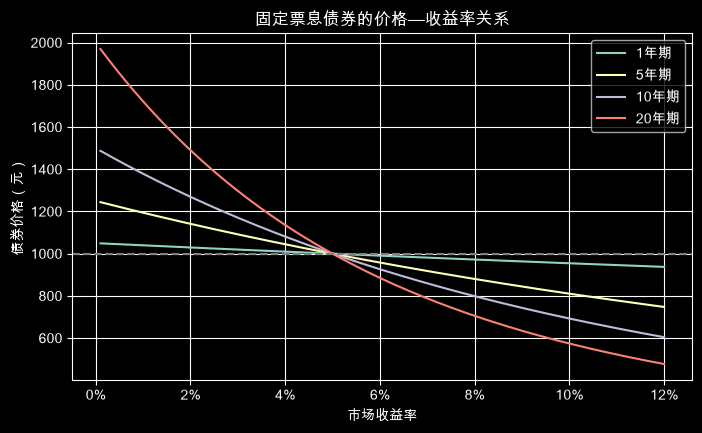

In [4]:
yields = np.linspace(0.001, 0.12, 200)
maturities = [1, 5, 10, 20]

fig, ax = plt.subplots()
for t in maturities:
    prices = [bond_price(1000, 0.05, t, y) for y in yields]
    ax.plot(yields, prices, label=f"{t}年期")
ax.axhline(1000, color="gray", linestyle="--")
ax.set(title="固定票息债券的价格—收益率关系", xlabel="市场收益率", ylabel="债券价格（元）")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend(); plt.show()

> **实验图读图卡｜价格—收益率曲线**
>
> - 横轴是市场收益率，纵轴是同一合同现金流的今天价格；颜色只区分到期期限。
> - 先找5%附近与1000元水平线的交点，再比较各曲线斜率。
> - 能观察到收益率上升时价格下降、长期曲线通常更陡；图没有加入违约、税费与流动性。


### 停下来核对

1. 哪种期限的曲线更陡？这意味着什么？
2. 曲线是直线吗？
3. 收益率从2%升到3%和从10%升到11%，价格变化是否完全相同？

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->


## 3.3 久期：现金流时间与价格敏感度

已有线索：3.2已观察到期限越长曲线通常越陡，但到期年数还没有考虑早期票息。本节要解决：**怎样用一个数概括现金流等待时间和小幅利率敏感度？**

Macaulay久期是现金流时点按其现值权重计算的平均时间：

$$D_M=\frac{\sum_t t\cdot PV(CF_t)}{P}$$

修正久期 $D_{mod}=D_M/(1+y)$ 给出小幅收益率变化下的价格近似：

$$\frac{\Delta P}{P}\approx-D_{mod}\Delta y$$

负号表达价格与收益率通常反向变化。

动手前先做：比较零息债与高票息债：谁更早收回更多现值，谁的平均等待时间更短？核对提示：计算每笔现值权重并检查权重和为1；Macaulay久期单位是年，`Δy`必须写成小数。

但是，久期是局部近似，不是保证；现金流越早，久期通常越低，小冲击下近似更可靠。


In [5]:
def bond_duration(face, coupon_rate, maturity, yield_rate):
    coupon = face * coupon_rate
    cash_flows = np.full(maturity, coupon, dtype=float)
    cash_flows[-1] += face
    times = np.arange(1, maturity + 1)
    pvs = cash_flows / (1 + yield_rate) ** times
    price = pvs.sum()
    macaulay = np.sum(times * pvs) / price
    modified = macaulay / (1 + yield_rate)
    return price, macaulay, modified


price0, macaulay, modified = bond_duration(1000, 0.05, 10, 0.05)
print({"价格": round(price0, 2), "Macaulay久期": round(macaulay, 4), "修正久期": round(modified, 4)})

{'价格': np.float64(1000.0), 'Macaulay久期': np.float64(8.1078), '修正久期': np.float64(7.7217)}


**数学连接：加权平均**

久期不是简单的到期年数。早期票息降低现金流的平均等待时间；零息债券只有到期一笔现金流，其Macaulay久期等于到期期限。


In [6]:
shocks = np.array([-0.02, -0.01, -0.0025, 0.0025, 0.01, 0.02])
rows = []
for shock in shocks:
    exact_price = bond_price(1000, 0.05, 10, 0.05 + shock)
    duration_price = price0 * (1 - modified * shock)
    rows.append({"收益率变化": shock, "精确价格": exact_price,
                 "久期近似": duration_price, "近似误差": duration_price - exact_price})
duration_check = pd.DataFrame(rows)
display(duration_check.style.format({"收益率变化": "{:+.2%}", "精确价格": "{:,.2f}",
                                     "久期近似": "{:,.2f}", "近似误差": "{:+.2f}"}))

,收益率变化,精确价格,久期近似,近似误差
0,-2.00%,"1,170.60","1,154.43",-16.17
1,-1.00%,"1,081.11","1,077.22",-3.89
2,-0.25%,"1,019.54","1,019.30",-0.24
3,+0.25%,980.93,980.70,-0.23
4,+1.00%,926.40,922.78,-3.62
5,+2.00%,859.53,845.57,-13.96


### 停下来核对

久期近似在小冲击还是大冲击时更准确？误差为什么表现出弯曲关系？这将引出凸性。

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->


## 3.4 凸性：用二阶项修正曲线弯曲

已有线索：先看3.3中“久期近似－精确价格”的误差，再使用高等数学的二阶导数直觉。本节要解决：**为什么一条切线无法在较大利率冲击下贴合弯曲的价格曲线？**

久期是一阶近似；价格—收益率曲线弯曲时，可加入凸性项：

$$\frac{\Delta P}{P}\approx-D_{mod}\Delta y+\frac{1}{2}Convexity(\Delta y)^2$$

本章用数值差分估计二阶敏感度，避免一次引入过多债券市场计数规则。

动手前先做：预测冲击从25 bp扩大到200 bp时，一阶近似误差如何变化。核对提示：中心差分用`y-step`、`y`、`y+step`估计斜率和弯曲度；`step`不是市场预测。

凸性项能改善本例的大冲击近似，但是不能覆盖违约、流动性或模型结构变化。


In [7]:
def numerical_duration_convexity(price_function, y, step=1e-4):
    p0 = price_function(y)
    p_up = price_function(y + step)
    p_down = price_function(y - step)
    modified_duration = -(p_up - p_down) / (2 * step * p0)
    convexity = (p_up - 2 * p0 + p_down) / (step**2 * p0)
    return modified_duration, convexity


price_fn = lambda y: bond_price(1000, 0.05, 10, y)
d_num, convexity = numerical_duration_convexity(price_fn, 0.05)
print({"数值修正久期": round(d_num, 4), "数值凸性": round(convexity, 4)})

{'数值修正久期': 7.7217, '数值凸性': 74.9977}


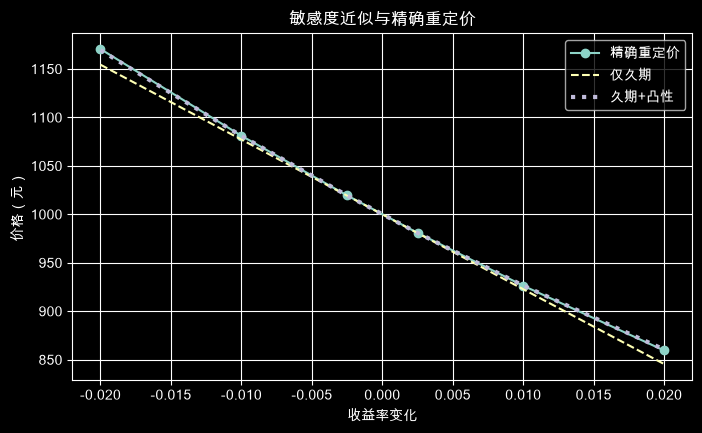

In [8]:
exact = np.array([price_fn(0.05 + s) for s in shocks])
duration_only = price0 * (1 - d_num * shocks)
duration_convexity = price0 * (1 - d_num * shocks + 0.5 * convexity * shocks**2)

plt.plot(shocks, exact, "o-", label="精确重定价")
plt.plot(shocks, duration_only, "--", label="仅久期")
plt.plot(shocks, duration_convexity, ":", linewidth=3, label="久期+凸性")
plt.xlabel("收益率变化"); plt.ylabel("价格（元）"); plt.title("敏感度近似与精确重定价")
plt.legend(); plt.show()

> **实验图读图卡｜精确重定价与近似**
>
> - 横轴是收益率变化（代码中为小数），纵轴是价格；三条线分别代表精确值、一阶久期和久期+凸性。
> - 先比较±25 bp，再比较±200 bp：冲击越大，一阶近似偏离越明显，二阶项在本例中更贴近精确值。
> - 这只检验数学近似误差，不能据此声称覆盖信用或流动性风险。


## 3.5 到期收益率：从价格反求利率

已有线索：这与第2章反求项目IRR是同一个“让函数等于零”的问题。本节要解决：**市场只给价格时，怎样反求使现金流现值等于价格的单一利率？**

市场给出价格时，可以数值求解使贴现现金流等于价格的收益率。它综合了当前价格和合同现金流，但依赖持有到期、再投资等解释条件。

动手前先做：票面利率5%的债券价格只有950元时，判断到期收益率高于还是低于5%。核对提示：理解二分夹逼，再看`brentq`；传入的函数、搜索上下界和利率单位都必须解释。

但是，本例约6.1932%；它是价格与合同现金流的汇总指标，不是实际持有收益保证。


In [9]:
from scipy.optimize import brentq

market_price = 950
solved_yield = brentq(lambda y: bond_price(1000, 0.05, 5, y) - market_price, -0.9, 2.0)
print(f"价格{market_price}元对应的到期收益率：{solved_yield:.4%}")
print("代回价格：", round(bond_price(1000, 0.05, 5, solved_yield), 6))

价格950元对应的到期收益率：6.1932%
代回价格： 950.0


## 3.6 不只有利率风险

已有线索：再用第1章“情景及其权重”，本节不建立正式概率模型。本节要解决：**合同写着1050元，是否等于一定能收到1050元？**

债券还可能面临：发行人不能按约付款的信用风险、难以及时成交的流动性风险、通胀侵蚀固定现金流购买力、提前赎回等合同条款风险。

一个高票息债券不一定“更好”：更高票息可能对应更高信用风险，价格也可能已经反映风险。

动手前先做：在可靠性不同但票息相同的两位发行人之间，判断高票息是否足以说明更好。核对提示：图中的“期望”只表示按教学假设权重计算的平均付款；第7章再正式学习概率与期望。

但是，直线下降来自固定的两种付款结局和人为权重，不是现实违约率估计；还要分别讨论流动性、通胀和合同条款。


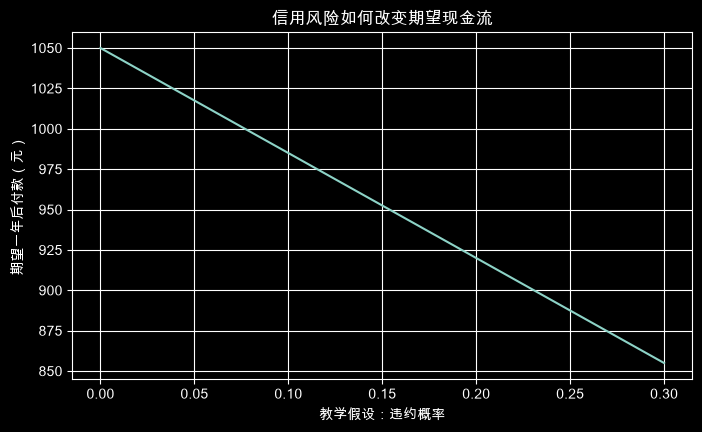

In [10]:
promised = 1_050
recovery = 400
default_probabilities = np.linspace(0, 0.30, 61)
expected_payments = (1 - default_probabilities) * promised + default_probabilities * recovery

plt.plot(default_probabilities, expected_payments)
plt.xlabel("教学假设：违约概率"); plt.ylabel("期望一年后付款（元）")
plt.title("信用风险如何改变期望现金流")
plt.show()

> **实验图读图卡｜情景权重预告**
>
> - 横轴是人为设定的违约情景权重，纵轴是两种付款结局的加权平均。
> - 直线下降是因为付款额和回收额都被固定；它不是用历史数据估计出的违约概率。
> - 第7章将正式学习随机变量、概率与期望；本节只复习第1章情景加权。


**量化编程警告**：上图只用两个结局，且把违约概率和回收额当作已知。现实信用建模必须处理估计误差、相关违约、迁徙和时间变化。


## 3.7 交互实验：自行设计一只简化债券

已有线索：综合3.1—3.6，但每次只改变一个参数。本节要解决：**票息、期限和市场收益率同时变化时，怎样有条理地比较？**

动手前先做：填三行预测：提高票息、提高市场收益率、延长期限分别会怎样，再运行静态函数；最后再操作滑块。核对提示：PyCharm可能只显示widget而不显示嵌套图，先直接调用`bond_lab(...)`作为静态后备。

但是，市场收益率上升通常压低价格；期限对价格水平的影响取决于票息与收益率关系，不能概括成“越长越便宜”。


In [11]:
def bond_lab(coupon_rate=0.05, maturity=10, market_yield=0.05):
    price = bond_price(1000, coupon_rate, maturity, market_yield)
    _, macaulay, modified = bond_duration(1000, coupon_rate, maturity, market_yield)
    print({"coupon_rate": coupon_rate, "maturity": maturity, "market_yield": market_yield,
           "price": round(price, 2), "modified_duration": round(modified, 3)})
    ys = np.linspace(max(0.001, market_yield - 0.04), market_yield + 0.04, 100)
    plt.plot(ys, [bond_price(1000, coupon_rate, maturity, y) for y in ys])
    plt.axvline(market_yield, color="red", linestyle="--")
    plt.xlabel("市场收益率"); plt.ylabel("价格"); plt.title("价格—收益率局部曲线"); plt.show()

try:
    from ipywidgets import interact, FloatSlider, IntSlider
    interact(bond_lab,
             coupon_rate=FloatSlider(value=.05, min=0, max=.12, step=.01, description="票面利率"),
             maturity=IntSlider(value=10, min=1, max=30, description="期限"),
             market_yield=FloatSlider(value=.05, min=.005, max=.15, step=.005, description="市场收益率"))
except ImportError:
    bond_lab()

interactive(children=(FloatSlider(value=0.05, description='票面利率', max=0.12, step=0.01), IntSlider(value=10, de…

> **实验图读图卡｜局部压力实验**
>
> - 红色竖线是当前市场收益率，曲线显示其附近收益率变化对应的价格。
> - 每次只改一个参数并保存关键数值；如果PyCharm只显示滑块，请直接调用`bond_lab(...)`获得静态图。
> - 参数敏感性不是预测，图外仍有信用、流动性与合同条款风险。


## 3.8 编程练习：补全半年付息债券定价

已有线索：再用3.1的定价函数，并检查每期现金流和每期利率是否同频。本节要解决：**如何把所有年口径一致转换为半年一期？**

输入均以年为单位；`frequency=2`表示半年付息。注意每期票息、每期收益率和总期数都必须转换。

动手前先做：年票息60元、2年、半年付息：手算每期票息、总期数和每期收益率。核对提示：应得到每期30元、4期、每期收益率3%；普通循环解释机制后再用数组。

但是，平价测试只是一个边界；还要检查零息债、不同频率和非法输入。


In [12]:
def student_bond_price(face, coupon_rate, maturity, yield_rate, frequency=2):
    # TODO：完成半年或其他频率付息债券的价格计算
    return None

In [13]:
answer = student_bond_price(1000, 0.06, 2, 0.06, frequency=2)
if answer is None:
    print("练习尚未完成。")
else:
    print("平价债券测试通过：", np.isclose(answer, 1000, atol=1e-8))

练习尚未完成。




### 我的解释

为什么长期债券通常比短期债券对收益率变化更敏感？票息提高又会怎样影响久期？

<!-- 在这里填写；完成前AI不要代答 -->

### AI批改区

<!-- 检查现金流时点、频率换算、价格方向和边界条件。 -->

## 项目交付：债券压力测试

已有线索：先回想本章所有术语，并为第4章的股权比较准备统一口径。本节要解决：**能否把合同现金流、利率敏感度和合同外风险放进同一张风险卡？**

制作一个债券压力测试器：比较2年、5年和10年固定利率债券；设置收益率±50/100/200个基点冲击；同时报告精确重定价、久期近似和误差；单独列出无法由久期覆盖的信用与流动性风险。

**参考**：Investor.gov Bonds；上海证券交易所投资者教育“债券专题”。

动手前先做：在运行前预测2/5/10年债在±50/100/200 bp下的价格排序和误差大小。核对提示：输出表必须同时保留精确重定价、近似值、误差和单位；凸性列可选。

但是，累计收益图不是本章证据；结论必须区分模型内利率风险和模型外信用、流动性风险。
